--- Equal-Weight Portfolio ---
Return:     16.71%
Volatility: 16.83%
Sharpe:     0.725

--- Max Sharpe Portfolio ---
Return:     19.58%
Volatility: 16.08%
Sharpe:     0.938
AAPL: 33.79%
BRK-B: 6.73%
GLD: 44.60%
GOOGL: 5.41%
JPM: 3.45%
MSFT: 2.44%
SPY: 3.02%
TLT: 0.56%

--- Min Variance Portfolio ---
Return:     6.35%
Volatility: 10.51%
Sharpe:     0.176
AAPL: 1.46%
BRK-B: 9.26%
GLD: 29.51%
GOOGL: 0.24%
JPM: 7.11%
MSFT: 3.95%
SPY: 2.27%
TLT: 46.21%


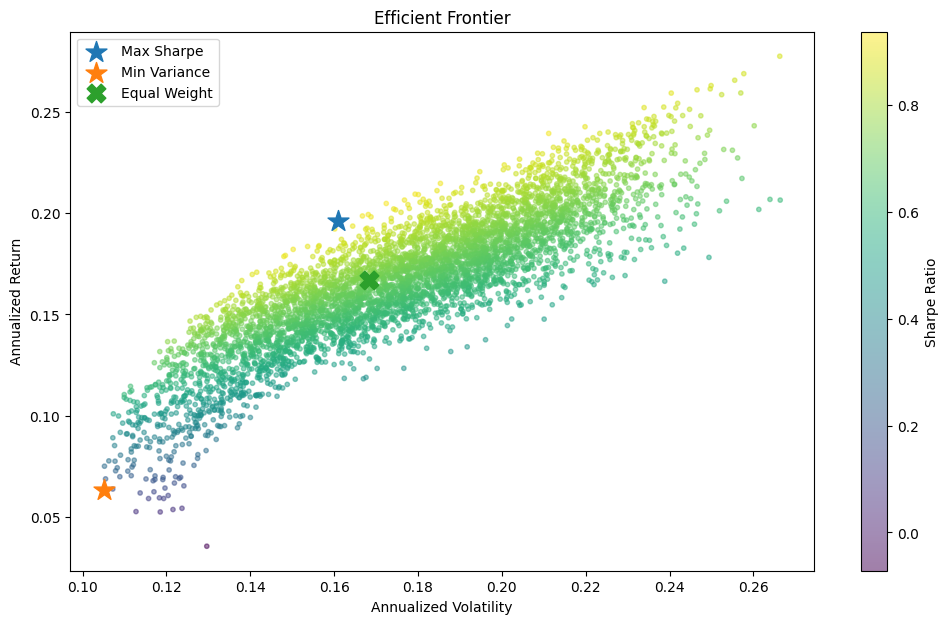

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load returns
log_returns = pd.read_csv("../data/log_returns.csv", index_col=0, parse_dates=True)

tickers = list(log_returns.columns)
n_assets = len(tickers)

# Annualized inputs
annual_returns = log_returns.mean() * 252
cov_matrix = log_returns.cov() * 252

# Current equal-weight portfolio
equal_weights = np.array([1 / n_assets] * n_assets)
equal_return = annual_returns.dot(equal_weights)
equal_vol = np.sqrt(equal_weights.T @ cov_matrix @ equal_weights)

risk_free_rate = 0.045

n_portfolios = 5000
results = np.zeros((3, n_portfolios))
weight_list = []

for i in range(n_portfolios):
    w = np.random.dirichlet(np.ones(n_assets))
    weight_list.append(w)

    port_return = annual_returns.dot(w)
    port_vol = np.sqrt(w.T @ cov_matrix @ w)
    port_sharpe = (port_return - risk_free_rate) / port_vol

    results[:, i] = [port_return, port_vol, port_sharpe]

max_sharpe_idx = np.argmax(results[2])
min_var_idx = np.argmin(results[1])

max_sharpe_weights = weight_list[max_sharpe_idx]
min_var_weights = weight_list[min_var_idx]

print("--- Equal-Weight Portfolio ---")
print(f"Return:     {equal_return:.2%}")
print(f"Volatility: {equal_vol:.2%}")
print(f"Sharpe:     {(equal_return - risk_free_rate) / equal_vol:.3f}")

print("\n--- Max Sharpe Portfolio ---")
print(f"Return:     {results[0, max_sharpe_idx]:.2%}")
print(f"Volatility: {results[1, max_sharpe_idx]:.2%}")
print(f"Sharpe:     {results[2, max_sharpe_idx]:.3f}")
for t, w in zip(tickers, max_sharpe_weights):
    print(f"{t}: {w:.2%}")

print("\n--- Min Variance Portfolio ---")
print(f"Return:     {results[0, min_var_idx]:.2%}")
print(f"Volatility: {results[1, min_var_idx]:.2%}")
print(f"Sharpe:     {results[2, min_var_idx]:.3f}")
for t, w in zip(tickers, min_var_weights):
    print(f"{t}: {w:.2%}")

plt.figure(figsize=(12, 7))
plt.scatter(results[1], results[0], c=results[2], alpha=0.5, s=10)
plt.colorbar(label="Sharpe Ratio")

plt.scatter(
    results[1, max_sharpe_idx],
    results[0, max_sharpe_idx],
    marker="*",
    s=250,
    label="Max Sharpe"
)

plt.scatter(
    results[1, min_var_idx],
    results[0, min_var_idx],
    marker="*",
    s=250,
    label="Min Variance"
)

plt.scatter(
    equal_vol,
    equal_return,
    marker="X",
    s=180,
    label="Equal Weight"
)

plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Efficient Frontier")
plt.legend()
plt.show()